In [97]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns


In [6]:
customer=pd.read_csv("Mall_Customers.csv")


In [7]:
customer=customer.rename(columns={"Annual Income (k$)":"Annual Income"})


In [8]:
customer

,CustomerID,Gender,Age,Annual Income,Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [9]:
customer.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income             0
Spending Score (1-100)    0
dtype: int64

In [10]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income           200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [11]:
customer.describe()

,CustomerID,Age,Annual Income,Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
customer.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

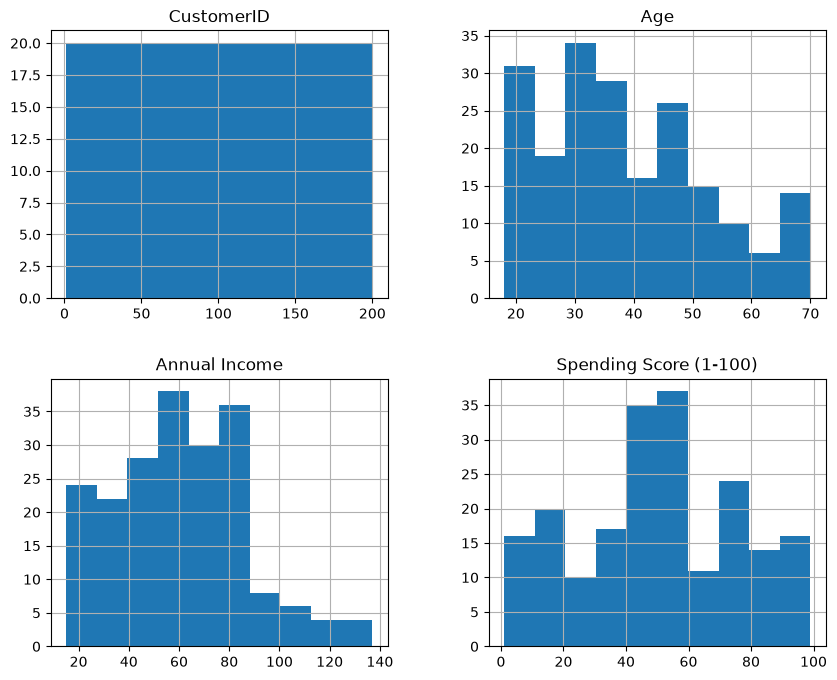

In [13]:
customer.hist(figsize=(10,8))

In [14]:
customer.corr(numeric_only=True)

,CustomerID,Age,Annual Income,Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income,0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


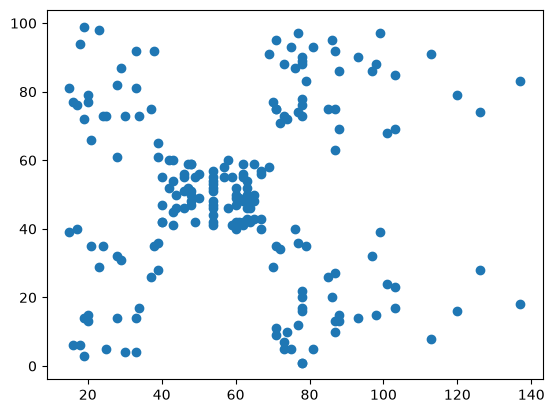

In [15]:
plt.scatter(customer["Annual Income"],customer["Spending Score (1-100)"])


In [16]:
le=LabelEncoder()
customer["Gender"]=le.fit_transform(customer["Gender"])

In [17]:
customer

,CustomerID,Gender,Age,Annual Income,Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [18]:
customer["age_group"]=pd.cut(customer["Age"],
                              bins=[0,18,30,45,60,100],
                              labels=["teen","young_adult","adult","middle_aged","senior"])

In [19]:
customer

,CustomerID,Gender,Age,Annual Income,Spending Score (1-100),age_group
0,1,1,19,15,39,young_adult
1,2,1,21,15,81,young_adult
2,3,0,20,16,6,young_adult
3,4,0,23,16,77,young_adult
4,5,0,31,17,40,adult
...,...,...,...,...,...,...
195,196,0,35,120,79,adult
196,197,0,45,126,28,adult
197,198,1,32,126,74,adult
198,199,1,32,137,18,adult


In [20]:
customer["income_spending_ratio"]=customer["Annual Income"]/customer["Spending Score (1-100)"]

In [21]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(customer[["Age","Annual Income","Spending Score (1-100)"]])

In [22]:
customer

,CustomerID,Gender,Age,Annual Income,Spending Score (1-100),age_group,income_spending_ratio
0,1,1,19,15,39,young_adult,0.384615
1,2,1,21,15,81,young_adult,0.185185
2,3,0,20,16,6,young_adult,2.666667
3,4,0,23,16,77,young_adult,0.207792
4,5,0,31,17,40,adult,0.425000
...,...,...,...,...,...,...,...
195,196,0,35,120,79,adult,1.518987
196,197,0,45,126,28,adult,4.500000
197,198,1,32,126,74,adult,1.702703
198,199,1,32,137,18,adult,7.611111


In [23]:
customer=customer.drop(columns="CustomerID")

In [24]:
customer

,Gender,Age,Annual Income,Spending Score (1-100),age_group,income_spending_ratio
0,1,19,15,39,young_adult,0.384615
1,1,21,15,81,young_adult,0.185185
2,0,20,16,6,young_adult,2.666667
3,0,23,16,77,young_adult,0.207792
4,0,31,17,40,adult,0.425000
...,...,...,...,...,...,...
195,0,35,120,79,adult,1.518987
196,0,45,126,28,adult,4.500000
197,1,32,126,74,adult,1.702703
198,1,32,137,18,adult,7.611111


In [29]:
x_scaled

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

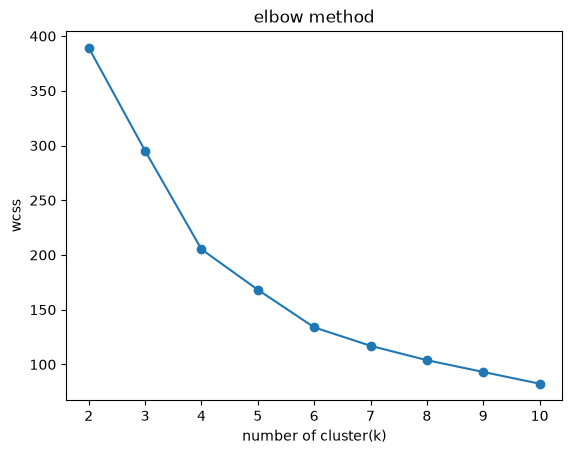

In [31]:
wcss=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("number of cluster(k)")
plt.ylabel("wcss")
plt.title("elbow method")
plt.show()

In [37]:
for k in range(2,12):
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=kmeans.fit_predict(x_scaled)
    score=silhouette_score(x_scaled,labels)
    print("k=",k,"score=",score)

k= 2 score= 0.33547192894004574
k= 3 score= 0.357793388710272
k= 4 score= 0.4039582785148566
k= 5 score= 0.41664341513732767
k= 6 score= 0.4284167762892593
k= 7 score= 0.417231894954916
k= 8 score= 0.4082067042807375
k= 9 score= 0.41769250624076476
k= 10 score= 0.40655411010117015
k= 11 score= 0.40861878459370105


In [76]:
kmeans=KMeans(n_clusters=6,random_state=42,n_init=10)
labels=kmeans.fit_predict(x_scaled)

In [77]:
customer["cluster"]=labels

In [78]:
customer

,Gender,Age,Annual Income,Spending Score (1-100),age_group,income_spending_ratio,cluster
0,1,19,15,39,young_adult,0.384615,4
1,1,21,15,81,young_adult,0.185185,4
2,0,20,16,6,young_adult,2.666667,5
3,0,23,16,77,young_adult,0.207792,4
4,0,31,17,40,adult,0.425000,5
...,...,...,...,...,...,...,...
195,0,35,120,79,adult,1.518987,3
196,0,45,126,28,adult,4.500000,2
197,1,32,126,74,adult,1.702703,3
198,1,32,137,18,adult,7.611111,2


,Age,Annual Income,Spending Score (1-100)
cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


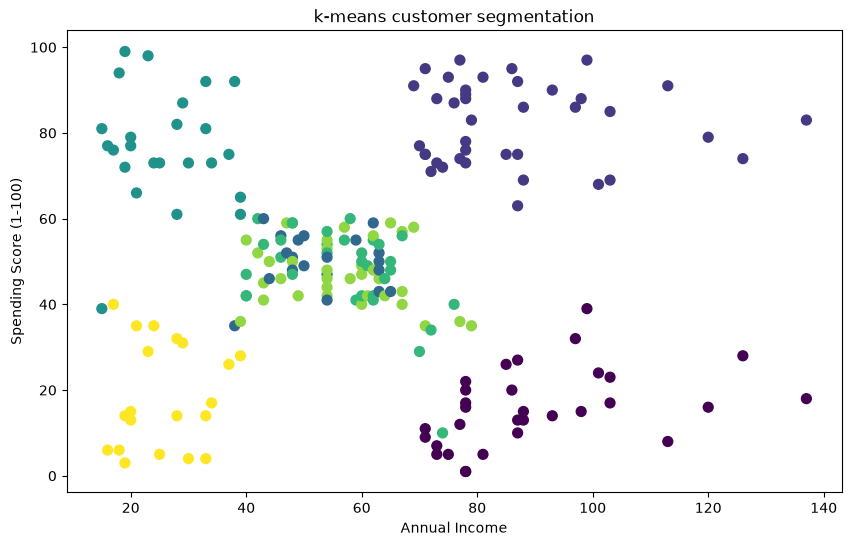

In [75]:
plt.figure(figsize=(10,6))
plt.scatter(customer["Annual Income"],customer["Spending Score (1-100)"],c=customer["cluster"],s=50)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
plt.title("k-means customer segmentation")
plt.show()


In [81]:
customer["cluster"].value_counts()

cluster
0    45
1    39
3    39
2    33
4    23
5    21
Name: count, dtype: int64

In [82]:
profile=customer.groupby("cluster")[["Age","Annual Income","Spending Score (1-100)"]].mean()
print(profile)

               Age  Annual Income  Spending Score (1-100)
cluster                                                  
0        56.333333      54.266667               49.066667
1        26.794872      57.102564               48.128205
2        41.939394      88.939394               16.969697
3        32.692308      86.538462               82.128205
4        25.000000      25.260870               77.608696
5        45.523810      26.285714               19.380952


In [83]:
cluster_names={
    0:"mature_mainsteram",
    1:"young_mainstream",
    2:"cautious_savers",
    3:"premium_customers",
    4:"young_impulsive_spenders",
    5:"budget_conscious"
}

customer["segment"]=customer["cluster"].map(cluster_names)

In [84]:
customer

,Gender,Age,Annual Income,Spending Score (1-100),age_group,income_spending_ratio,cluster,segment
0,1,19,15,39,young_adult,0.384615,4,young_impulsive_spenders
1,1,21,15,81,young_adult,0.185185,4,young_impulsive_spenders
2,0,20,16,6,young_adult,2.666667,5,budget_conscious
3,0,23,16,77,young_adult,0.207792,4,young_impulsive_spenders
4,0,31,17,40,adult,0.425000,5,budget_conscious
...,...,...,...,...,...,...,...,...
195,0,35,120,79,adult,1.518987,3,premium_customers
196,0,45,126,28,adult,4.500000,2,cautious_savers
197,1,32,126,74,adult,1.702703,3,premium_customers
198,1,32,137,18,adult,7.611111,2,cautious_savers


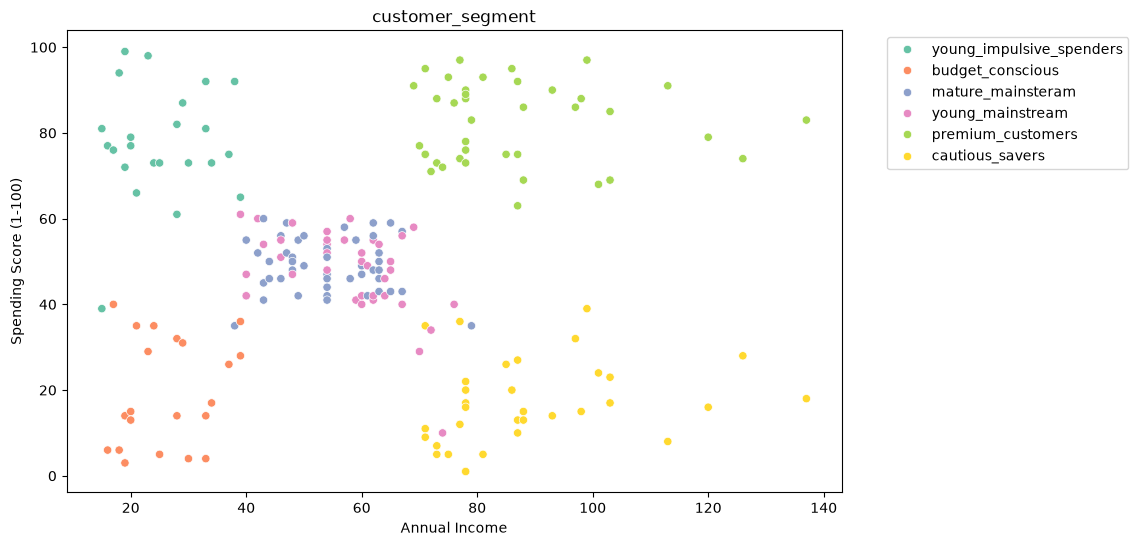

In [87]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=customer,x="Annual Income",y="Spending Score (1-100)",hue="segment",palette="Set2")
plt.title("customer_segment")
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

In [98]:
os.makedirs("images",exist_ok=True)

In [99]:
plt.savefig("images/final_clusters.png",dpi=150,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [100]:
customer.to_csv("mall_segments.csv",index=False)